In [1]:
import warnings

import logomaker
import matplotlib.pyplot as plt
import pandas as pd
import torch
from Levenshtein import distance


In [2]:
from pep_compass.models.encoder_decoder.hydramp_encoder_decoder import HydrAMPEncoderDecoder


DEVICE = "cuda:3"
encoder_decoder = HydrAMPEncoderDecoder(device=DEVICE)

In [3]:
start_peptide = "GLFDIAKKVIGVIGSL"
end_peptide = "WRSLGRTLLRLSCALKKLARRSGW"

In [4]:
NUM_COMP = [0, 3]
TEMP = 1.3

begin = encoder_decoder.encode_peptides([start_peptide])[0]

end = encoder_decoder.encode_peptides([end_peptide])[0]

latent_euc_dist = torch.dist(begin, end, p=2)

In [5]:
latent_euc_dist

tensor(7.5989, device='cuda:3', grad_fn=<DistBackward0>)

In [6]:
from pep_compass.geodesic_search.geodesics import Geodesics


geo_lin = Geodesics(
    encoder_decoder=encoder_decoder,
    device=DEVICE,
    lr=0.001,
    patience=100,
    convergence_tol=1e-8,
    weight_ambient_dist=0.01,
    weight_latent_dist=0.1,
    weight_var=200,
    metric=["antex"],
    models_path="../models"
)


/raid/adambiel/venvs/pep-compass-2/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/raid/adambiel/venvs/pep-compass-2/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened bec

In [7]:
geodesics_line, geo_length = geo_lin.find(
    end=end, begin=begin, num_iterations=2000, verbose=True
)

geo_length

iteration=0, loss=56.06203079223633, ambient_dist=45.1008203125, latent_dist=0.854595947265625, var=10.201316326856613, lr=[0.001]
iteration=1, loss=79.33209991455078, ambient_dist=52.7484765625, latent_dist=0.9588018417358399, var=25.72903037071228, lr=[0.001]
iteration=2, loss=75.34244537353516, ambient_dist=52.5094482421875, latent_dist=0.9203416824340821, var=21.87419831752777, lr=[0.001]
iteration=3, loss=67.79438018798828, ambient_dist=49.447285156250004, latent_dist=0.9288612365722657, var=17.4267515540123, lr=[0.001]
iteration=4, loss=67.97015380859375, ambient_dist=49.8321533203125, latent_dist=0.9186260223388673, var=17.209145426750183, lr=[0.001]
iteration=5, loss=65.77009582519531, ambient_dist=49.0630859375, latent_dist=0.8919528007507325, var=15.788386762142181, lr=[0.001]
iteration=6, loss=63.16462326049805, ambient_dist=47.748515625, latent_dist=0.8775047302246094, var=14.524154365062714, lr=[0.001]
iteration=7, loss=61.97954559326172, ambient_dist=47.211943359375, late

3616.80029296875

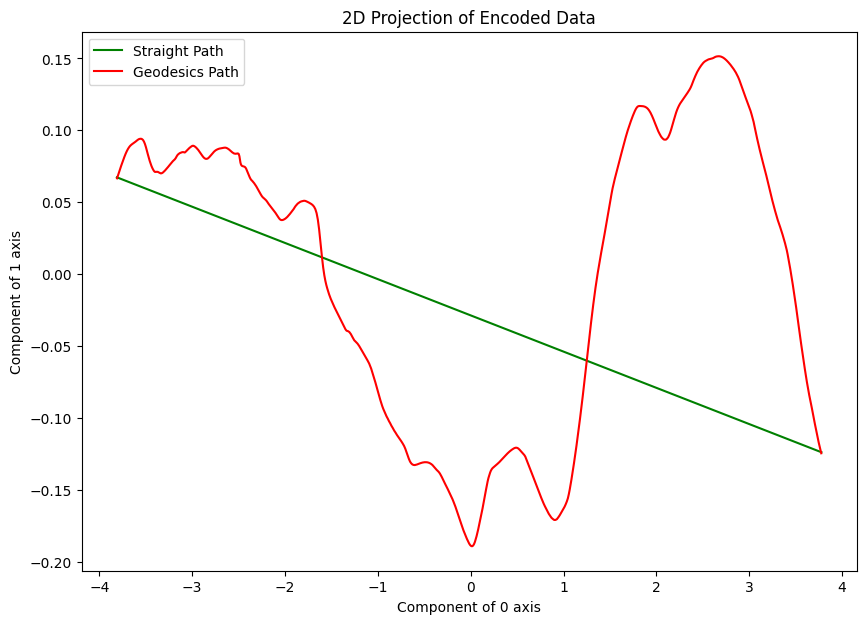

In [ ]:
from sklearn.decomposition import PCA

NUM_COMP = [0, 1]


geodesisc_line_numpy = geodesics_line.cpu().detach().numpy()

pca = PCA()
geodesisc_line_numpy = pca.fit_transform(geodesisc_line_numpy)


straight_line = torch.stack(
    [
        begin + (i / (geo_lin.n_points - 1)) * (end - begin)
        for i in range(geo_lin.n_points)
    ],
    dim=0,
)

straight_line_numpy = straight_line.cpu().detach().numpy()
straight_line_numpy = pca.transform(straight_line_numpy)

plt.figure(figsize=(10, 7))


plt.plot(
    straight_line_numpy[:, NUM_COMP[0]],
    straight_line_numpy[:, NUM_COMP[1]],
    color="green",
    linewidth=1.5,
    label="Straight Path",
)
plt.plot(
    geodesisc_line_numpy[:, NUM_COMP[0]],
    geodesisc_line_numpy[:, NUM_COMP[1]],
    color="red",
    linewidth=1.5,
    label="Geodesics Path",
)
plt.xlabel(f"Component of {NUM_COMP[0]} axis")
plt.ylabel(f"Component of {NUM_COMP[1]} axis")
plt.title("2D Projection of Encoded Data")
plt.legend()
plt.show()


In [9]:
def find_significant_changes_and_reversions(peptide_list):
    """
    Znajduje indeksy, gdzie nastąpiły zmiany w peptydach (dystans Levenshteina >= 1),
    oraz indeksy, gdzie sekwencje wróciły do poprzedniego stanu.

    Args:
        peptide_list (list): Lista peptydów jako stringi.

    Returns:
        tuple:
            - significant_indices (list): Indeksy zmian w peptydach.
            - reversion_indices (list): Indeksy, gdzie peptyd wrócił do poprzedniego stanu.
    """
    significant_indices = [0]
    reversion_indices = []

    previous_peptides = {}

    for i in range(1, len(peptide_list)):
        dist = distance(peptide_list[i - 1], peptide_list[i])

        if dist >= 1:
            significant_indices.append(i)

        for _, prev_peptide in previous_peptides.items():
            if (
                peptide_list[i] == prev_peptide
                and peptide_list[i] != peptide_list[i - 1]
            ):
                reversion_indices.append(i)
                break

        previous_peptides[i] = peptide_list[i]

    significant_indices.append(len(peptide_list) - 1)
    significant_indices = list(set(significant_indices))

    return significant_indices, reversion_indices

In [14]:
def translate_generated_peptide(encoded_peptide):
    alphabet = list("ACDEFGHIKLMNPQRSTVWY")
    return "".join(
        [
            alphabet[el - 1] if el != 0 else ""
            for el in encoded_peptide[0].argmax(axis=1)
        ]
    )


def translate_peptide(encoded_peptide):
    alphabet = list("ACDEFGHIKLMNPQRSTVWY")
    return "".join([alphabet[el - 1] if el != 0 else "" for el in encoded_peptide])


generated_geodesics = []
decoded_geodesics = []

generated_straight = []
decoded_straight = []

for i in range(len(geodesics_line)):
    decoded_geodesics_raw = encoder_decoder.decoder_forward(
        geodesics_line[i], softmax=False, flatten=False,
    )
    decoded_geodesic = torch.softmax(decoded_geodesics_raw / TEMP, dim=-1)

    decoded_geodesics.append(decoded_geodesic)
    translated_peptide = translate_generated_peptide(decoded_geodesic)
    generated_geodesics.append(translated_peptide)

    decoded_straight_raw = encoder_decoder.decoder_forward(
        straight_line[i], softmax=False, flatten=False,
    )
    decoded_straight_line = torch.softmax(decoded_straight_raw / TEMP, dim=-1)

    decoded_straight.append(decoded_straight_line)
    translated_peptide = translate_generated_peptide(decoded_straight_line)
    generated_straight.append(translated_peptide)


significant_indices_geodesics, _ = find_significant_changes_and_reversions(
    generated_geodesics
)
significant_indices_straight, _ = find_significant_changes_and_reversions(
    generated_straight
)

# print(f'Geodesics Path: {generated_geodesics}')
# print(f'Straight Path: {generated_straight}')


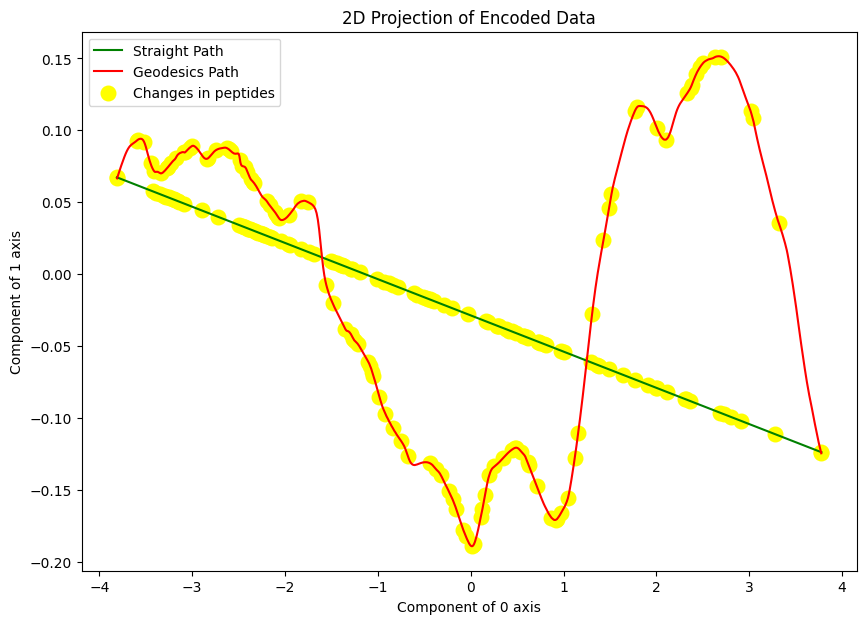

In [16]:
geodesisc_line_numpy = geodesics_line.cpu().detach().numpy()

pca = PCA()
geodesisc_line_numpy = pca.fit_transform(geodesisc_line_numpy)


straight_line = torch.stack(
    [
        begin + (i / (geo_lin.n_points - 1)) * (end - begin)
        for i in range(geo_lin.n_points)
    ],
    dim=0,
)

straight_line_numpy = straight_line.cpu().detach().numpy()
straight_line_numpy = pca.transform(straight_line_numpy)

# Step 4: Plotting
plt.figure(figsize=(10, 7))


plt.plot(
    straight_line_numpy[:, NUM_COMP[0]],
    straight_line_numpy[:, NUM_COMP[1]],
    color="green",
    linewidth=1.5,
    label="Straight Path",
)
plt.plot(
    geodesisc_line_numpy[:, NUM_COMP[0]],
    geodesisc_line_numpy[:, NUM_COMP[1]],
    color="red",
    linewidth=1.5,
    label="Geodesics Path",
)

plt.scatter(
    geodesisc_line_numpy[significant_indices_geodesics, NUM_COMP[0]],
    geodesisc_line_numpy[significant_indices_geodesics, NUM_COMP[1]],
    color="yellow",
    linewidth=1.5,
    s=100,
)
plt.scatter(
    straight_line_numpy[significant_indices_straight, NUM_COMP[0]],
    straight_line_numpy[significant_indices_straight, NUM_COMP[1]],
    color="yellow",
    linewidth=1.5,
    s=100,
    label="Changes in peptides",
)

plt.xlabel(f"Component of {NUM_COMP[0]} axis")
plt.ylabel(f"Component of {NUM_COMP[1]} axis")
plt.title("2D Projection of Encoded Data")
plt.legend()
plt.show()






In [20]:
time_series_geodesics = [decoded_geodesics[i] for i in significant_indices_geodesics]
time_series_straight = [decoded_straight[i] for i in significant_indices_straight]

amino_acids = [
    " ",
    "A",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "K",
    "L",
    "M",
    "N",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "V",
    "W",
    "Y",
]


def plot_logo(matrix, ax, title="", verbose=False):

    if not verbose:
        warnings.filterwarnings("ignore")
    df = pd.DataFrame(matrix.T, columns=amino_acids)
    df.index.name = "pos"

    logo = logomaker.Logo(df, ax=ax)
    logo.style_spines(visible=False)
    logo.style_xticks(anchor=0, spacing=1)

    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Probability")


fig, axs = plt.subplots(
    len(time_series_geodesics), 1, figsize=(16, 3 * len(time_series_geodesics))
)
axs = axs.flatten()

for i, matrix in enumerate(time_series_geodesics):
    plot_logo(
        matrix.squeeze(0).T.cpu().detach().numpy(), axs[i], title=f"Timepoint {i + 1}"
    )

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(
    len(time_series_straight), 1, figsize=(16, 3 * len(time_series_straight))
)
axs = axs.flatten()

for i, matrix in enumerate(time_series_straight):
    plot_logo(
        matrix.squeeze(0).T.cpu().detach().numpy(), axs[i], title=f"Timepoint {i + 1}"
    )

plt.tight_layout()
plt.show()
